Text(17.5, 15, 'Expansion Range')

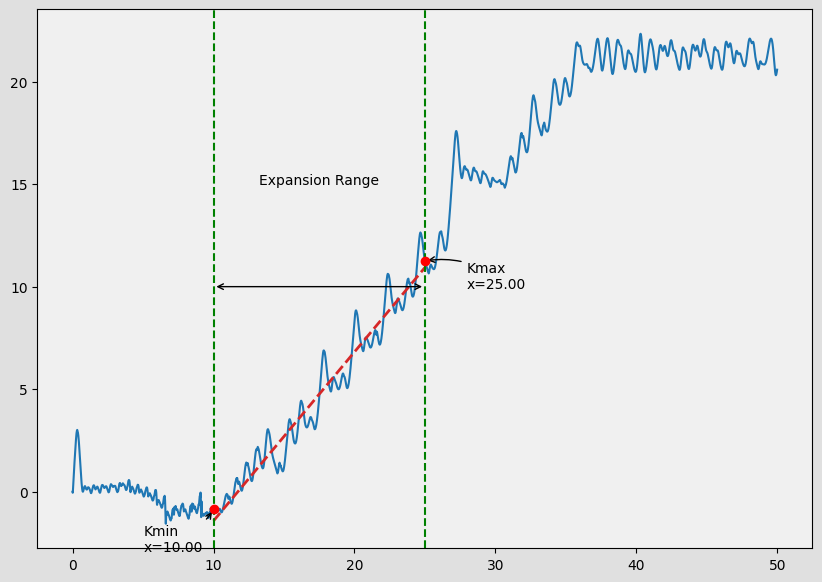

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Parametry układu Lorenza
sigma, r, b = 10.0, 28.0, 8/3.0

def lorenz(t, state):
    x, y, z = state
    return [sigma*(y - x), x*(r - z) - y, x*y - b*z]

# 2. Symulacja dwóch trajektorii bardzo blisko siebie
dt = 0.01
t_max = 50
t_eval = np.arange(0, t_max, dt)

dist_0 = 1e-8  # Początkowa perturbacja (bardzo mała)
state1 = np.array([1.0, 1.0, 1.0])
state2 = state1 + np.array([dist_0, 0, 0])

sol1 = solve_ivp(lorenz, (0, t_max), state1, t_eval=t_eval, method='RK45')
sol2 = solve_ivp(lorenz, (0, t_max), state2, t_eval=t_eval, method='RK45')

# 3. Obliczanie odległości i logarytmu dywergencji
# d(t) = sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
distances = np.linalg.norm(sol1.y - sol2.y, axis=0)
log_divergence = np.log(distances / dist_0)

# 4. Wybór zakresu do dopasowania liniowego (Expansion Range)
# Wybieramy zakres, gdzie wzrost jest liniowy (zanim nastąpi nasycenie)
k_min, k_max = 1000, 2500
x_fit = t_eval[k_min:k_max]
y_fit = log_divergence[k_min:k_max]

# Regresja liniowa (polyfit stopnia 1)
coeffs = np.polyfit(x_fit, y_fit, 1)
lambda_max = coeffs[0]
linear_line = np.polyval(coeffs, x_fit)

# 5. Wykres wzorowany na Twoim obrazku
plt.figure(figsize=(10, 7), facecolor='#e0e0e0')
ax = plt.axes()
ax.set_facecolor('#f0f0f0')

plt.plot(t_eval, log_divergence, label='Original Data', color='#1f77b4', linewidth=1.5)
plt.plot(x_fit, linear_line, '--', color='#d62728', label='Linear Fit', linewidth=2)

# Linie pionowe dla zakresu
plt.axvline(t_eval[k_min], color='green', linestyle='--')
plt.axvline(t_eval[k_max], color='green', linestyle='--')

# Oznaczenia punktów Kmin i Kmax
plt.scatter([t_eval[k_min], t_eval[k_max]], [log_divergence[k_min], log_divergence[k_max]], color='red', zorder=5)

# Adnotacje (strzałki i teksty)
plt.annotate(f'Kmin\nx={t_eval[k_min]:.2f}', xy=(t_eval[k_min], log_divergence[k_min]), xytext=(-50, -30),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))
plt.annotate(f'Kmax\nx={t_eval[k_max]:.2f}', xy=(t_eval[k_max], log_divergence[k_max]), xytext=(30, -20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

# Strzałka Expansion Range
plt.annotate('', xy=(t_eval[k_min], 10), xytext=(t_eval[k_max], 10),
             arrowprops=dict(arrowstyle='<->', color='black'))
plt.text((t_eval[k_min]+t_eval[k_max])/2, 15, 'Expansion Range', ha='center')


In [3]:
x1, x2, x = sp.symbols('x1 x2 x')

# Definicja układu równań
f1 = x1**2 - 2*x1
f2 = 1/x2 - x1 + 1

# 1. Wyznaczenie punktów równowagi (f1=0, f2=0)
points = sp.solve([f1, f2], [x1, x2])
print(f"Znalezione punkty równowagi (x1, x2): {points}")

# 2. Obliczenie macierzy Jacobiego
f = sp.Matrix([f1, f2])
vars = sp.Matrix([x1, x2])
J = f.jacobian(vars)
print(f"\nMacierz Jacobiego J(x1, x2):\n{J}")

# 3. Analiza stabilności dla punktu (2, 1) 
P = (2, 1)
J_at_P = J.subs({x1: P[0], x2: P[1]})
eigenvals = J_at_P.eigenvals()

print(f"\nMacierz Jacobiego w punkcie {P}:\n{J_at_P}")
print(f"Wartości własne: {list(eigenvals.keys())}")

# Weryfikacja stabilności 
if any(sp.re(lam) > 0 for lam in eigenvals):
    print("WNIOSEK: Punkt jest NIESTABILNY, ponieważ jedna wartość własna > 0.")
else:
    print("WNIOSEK: Punkt jest stabilny.")

Znalezione punkty równowagi (x1, x2): [(0, -1), (2, 1)]

Macierz Jacobiego J(x1, x2):
Matrix([[2*x1 - 2, 0], [-1, -1/x2**2]])

Macierz Jacobiego w punkcie (2, 1):
Matrix([[2, 0], [-1, -1]])
Wartości własne: [2, -1]
WNIOSEK: Punkt jest NIESTABILNY, ponieważ jedna wartość własna > 0.


In [4]:
x1, x2, x = sp.symbols('x1 x2 x')

# Definicja układu i funkcji Lapunowa
dx_dt = -x
V = x**2

# Obliczenie pochodnej V po czasie: dV/dt = (dV/dx) * (dx/dt) 
dV_dx = sp.diff(V, x)
V_dot = dV_dx * dx_dt

print(f"Funkcja Lapunowa V(x) = {V}")
print(f"Pochodna dV/dx = {dV_dx}")
print(f"Pochodna po czasie V_dot = {V_dot}")

# Sprawdzenie określoności 
if V_dot.subs(x, 1) < 0 and V_dot.subs(x, -1) < 0:
    print("\nWNIOSEK: V_dot jest ujemnie określona.")
    print("Układ jest ASYMPTOTYCZNIE STABILNY.")

Funkcja Lapunowa V(x) = x**2
Pochodna dV/dx = 2*x
Pochodna po czasie V_dot = -2*x**2

WNIOSEK: V_dot jest ujemnie określona.
Układ jest ASYMPTOTYCZNIE STABILNY.
